In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

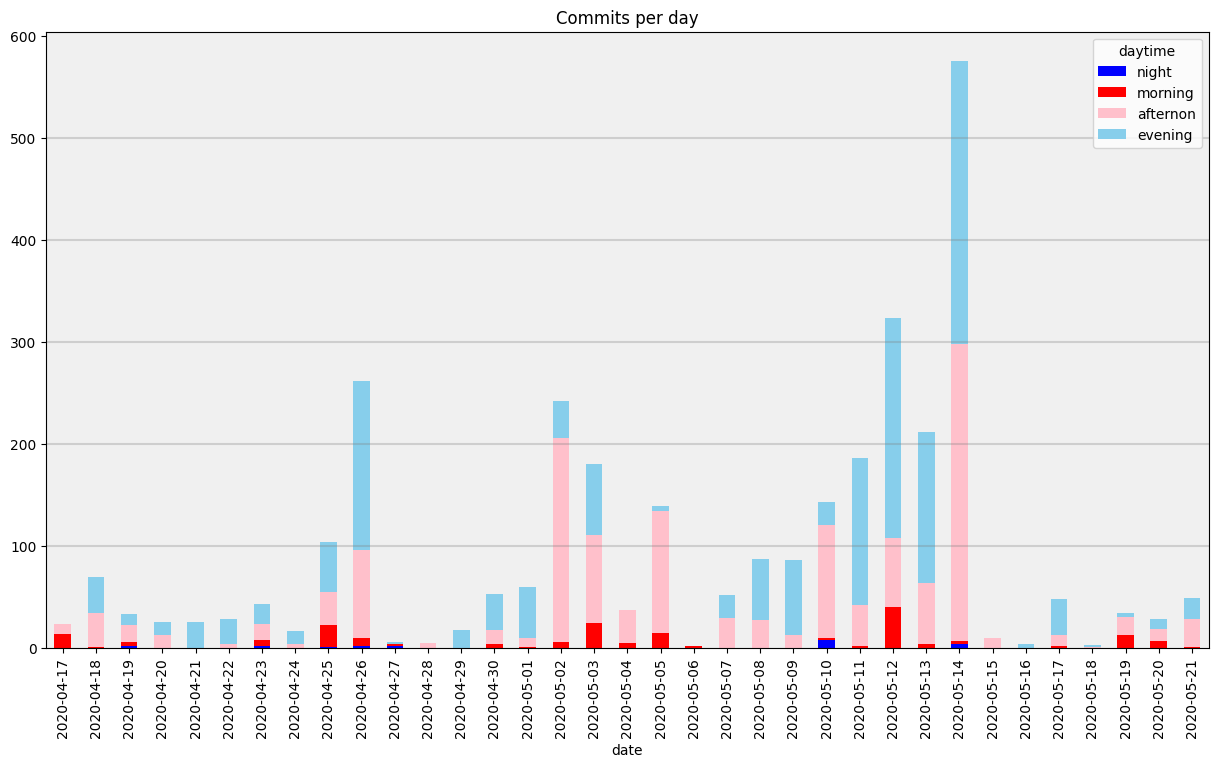

In [3]:
query = '''
SELECT 
    timestamp 
FROM 
    checker
WHERE 
    uid LIKE 'user%'
'''

df = pd.read_sql_query(query, conn)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
bins = [0, 240, 600, 1020, 1440]
labels = ["night", "morning", "afternon", "evening"]
df["daytime"] = pd.cut((df["hour"] * 60 + df["minute"]), bins=bins, labels=labels, right=False, include_lowest=True)

grouped = df.groupby(df['timestamp'].dt.date)['daytime'].value_counts().unstack(fill_value=0).reset_index()
ax = grouped.plot(
    kind='bar',
    x='timestamp',
    stacked=True,
    color=['blue', 'red', 'pink', 'skyblue'],
    figsize=(15, 8),
    xlabel = 'date',
    title = 'Commits per day'
)

ax.set_facecolor('#f0f0f0')

for y in range(100, 600, 100):
    ax.axhline(y=y, color='gray', alpha=0.3)

In [4]:
grouped[['night', 'morning', 'afternon', 'evening']].sum()

daytime
night         21
morning      184
afternon    1391
evening     1611
dtype: int64

## Answer: Afternoon, Evening

In [5]:
grouped['count_commits'] = grouped['night'] + grouped['morning'] + grouped['afternon'] + grouped['evening']
sorted_grouped = grouped.sort_values(by='count_commits', ascending=False)


for i in range(sorted_grouped.shape[0]):
    if sorted_grouped.iloc[i]['evening'] > sorted_grouped.iloc[i]['afternon']:
        print(sorted_grouped.iloc[i])
        break

daytime
timestamp        2020-05-12
night                     0
morning                  40
afternon                 68
evening                 215
count_commits           323
Name: 25, dtype: object


## Answer: 2020-05-12

In [6]:
conn.close()